# Figure C1 — State gradients and placebo distributions across worker-flow outcomes

Every number is read from an aggregate result artifact in `../artifacts/` — the files the submitted manuscript's tables were generated from.
No licensed microdata is used or required (see `../DATA_ACCESS.md`). Outputs are stored, so the notebook renders on GitHub without running.
The code below is cut verbatim from the paper's figure builder; the last cell checks the regenerated PNG against the image embedded in the submitted .docx.


## Setup


In [ ]:
import json, os, csv, io
import numpy as np
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
ART, EX = "../artifacts", "."
J = lambda f: json.load(open(os.path.join(ART, f + ".json"), encoding="utf-8"))
L = {r["claim_id"]: r for r in csv.DictReader(open(os.path.join(ART, "CLAIMS_LEDGER.csv"), encoding="utf-8-sig"))}
c = lambda cid, w="value": L[cid][w]
_figs = []
def SAVE(fig, n):
    for e in ("png", "pdf"): fig.savefig(f"{EX}/{n}.{e}", dpi=200, bbox_inches="tight")
    b = io.BytesIO(); fig.savefig(b, format="png", dpi=110, bbox_inches="tight"); _figs.append(b.getvalue())


## Build


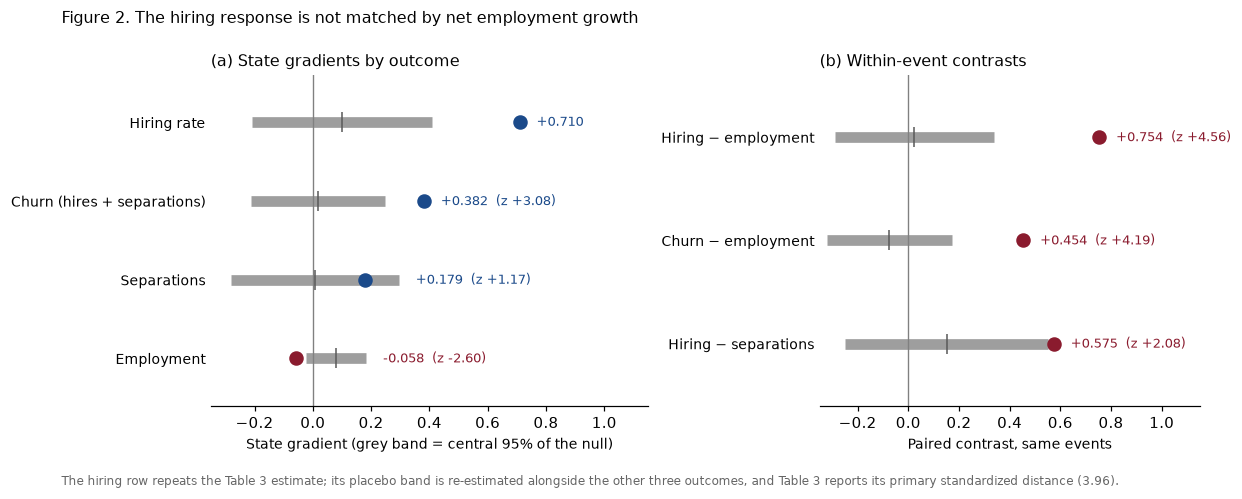

saved figure2_turnover.png / .pdf


In [ ]:

# ════════════ Figure 5 — 정체가 성장이 아니라 순환으로 ════════════
i57 = J("I57")["estimates"]
PBo, PCo = i57["panelB_outcomes"], i57["panelC_paired"]
ROWS5 = [("Hiring rate", PBo["hire"], 0), ("Churn (hires + separations)", PBo["churn"], 0),
         ("Separations", PBo["sep"], 0), ("Employment", PBo["emp"], 1)]
PAIR = [("Hiring − employment", PCo["채용 − 고용"]), ("Churn − employment", PCo["churn − 고용"]),
        ("Hiring − separations", PCo["채용 − 이직"])]
fig, ax = plt.subplots(1, 2, figsize=(11.6, 3.9),
                       gridspec_kw={"width_ratios": [1.15, 1], "wspace": .42})
a0 = ax[0]
a0.axvline(0, color="0.5", lw=.9)
for i, (lab, r, flip) in enumerate(ROWS5):
    y = len(ROWS5) - 1 - i
    mu, sd, obs = r["null_mean"], r["null_sd"], r["observed"]
    col = "#8a1b2e" if flip else "#1b4a8a"
    a0.plot([mu - 1.96 * sd, mu + 1.96 * sd], [y, y], color="0.62", lw=7,
            solid_capstyle="butt", zorder=1)
    a0.plot([mu], [y], "|", ms=13, color="0.35", zorder=2)
    a0.plot([obs], [y], "o", ms=8.5, color=col, zorder=4)
    xa = max(obs, mu + 1.96 * sd)          # 점이 귀무 띠 안이면 띠 밖으로 밀어 겹침 방지
    a0.annotate(f"{obs:+.3f}" if lab.startswith("Hiring") else f"{obs:+.3f}  (z {r['z']:+.2f})",   # hiring z lives in Table 3
                xy=(xa, y), xytext=(11, 0),
                textcoords="offset points", va="center", fontsize=8.4, color=col)
a0.set_yticks(range(len(ROWS5)))
a0.set_yticklabels([r[0] for r in ROWS5][::-1], fontsize=9)
a0.set_xlim(-0.35, 1.15); a0.set_ylim(-0.6, len(ROWS5) - 0.4)
a0.set_xlabel("State gradient (grey band = central 95% of the null)", fontsize=9)
a0.set_title("(a) State gradients by outcome", fontsize=10.4, loc="left")
a0.spines[["top", "right", "left"]].set_visible(False); a0.tick_params(axis="y", length=0)
a1 = ax[1]
a1.axvline(0, color="0.5", lw=.9)
for i, (lab, r) in enumerate(PAIR):
    y = len(PAIR) - 1 - i
    mu, sd, obs = r["null_mean"], r["null_sd"], r["observed"]
    a1.plot([mu - 1.96 * sd, mu + 1.96 * sd], [y, y], color="0.62", lw=7,
            solid_capstyle="butt", zorder=1)
    a1.plot([mu], [y], "|", ms=13, color="0.35", zorder=2)
    a1.plot([obs], [y], "o", ms=8.5, color="#8a1b2e", zorder=4)
    xa = max(obs, mu + 1.96 * sd)
    a1.annotate(f"{obs:+.3f}  (z {r['z']:+.2f})", xy=(xa, y), xytext=(11, 0),
                textcoords="offset points", va="center", fontsize=8.4, color="#8a1b2e")
a1.set_yticks(range(len(PAIR)))
a1.set_yticklabels([r[0] for r in PAIR][::-1], fontsize=9)
a1.set_xlim(-0.35, 1.15); a1.set_ylim(-0.6, len(PAIR) - 0.4)
a1.set_xlabel("Paired contrast, same events", fontsize=9)
a1.set_title("(b) Within-event contrasts", fontsize=10.4, loc="left")
a1.spines[["top", "right", "left"]].set_visible(False); a1.tick_params(axis="y", length=0)
fig.suptitle("Figure 2. The hiring response is not matched by net employment growth",
             fontsize=10.2, y=1.03, x=.008, ha="left")
fig.text(.008, -0.075, "The hiring row repeats the Table 3 estimate; its placebo band is re-estimated alongside the other three outcomes, "
         "and Table 3 reports its primary standardized distance (3.96).", fontsize=7.6, color="0.4", ha="left")
SAVE(fig, "figure2_turnover"); plt.close(fig); print("saved figure2_turnover.png / .pdf")


## Check


In [ ]:
import hashlib
a = hashlib.sha256(open("figure2_turnover.png", "rb").read()).hexdigest()
b = hashlib.sha256(open("../paper_exhibits/figureC1_worker_flows.png", "rb").read()).hexdigest()
print("regenerated PNG sha256 ==", "image embedded in the submitted .docx" if a == b else "DIFFERS", a[:16]); assert a == b


regenerated PNG sha256 == image embedded in the submitted .docx 20fc0a5099867c85
